## <font style="color:darkorange; font-weight:700;">What is Linear Regression?</font>

- Linear Regression is a statistical method used in ***Machine Learning to model the relationship between one or more independent variables (predictors) and a dependent variable (target)***.
  
- The ***main goal of linear regression is to find the best-fit line (linear relationship) that minimizes the error*** between `predicted values` and `actual values`.

Below table represents current home prices in monroe township based on square feet area, new jersey:

<img src="img/0.jpg" alt="price-table" style="height:150px;">

### **Problem Statement**: Given above data build a machine learning model that can predict home prices based on square feet area

You can represent values in above table as a scatter plot (values are shown in red markers). After that one can draw a straight line that best fits values on chart.

<img src="img/1.jpg" alt="price-table" style="height:300px;">

We can draw multiple lines like this but we choose the one where total sum of error is minimum

<img src="img/2.jpg" alt="price-table" style="height:300px;">

### From our school/cllg we know the equation of straight line: **`y=mx+c`**

Home prices can be presented as following equation,
***`home price = m * (area) + b`***
Generic form of same equation is,

<img src="img/3.png" alt="price-table" style="height:350px;">

In [1]:
# If warning occurs run this code
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

In [2]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from sklearn import linear_model

In [3]:
df = pd.read_csv("homeprices.csv")
df

,area,price
0,2600,550000
1,3000,565000
2,3200,610000
3,3600,680000
4,4000,725000


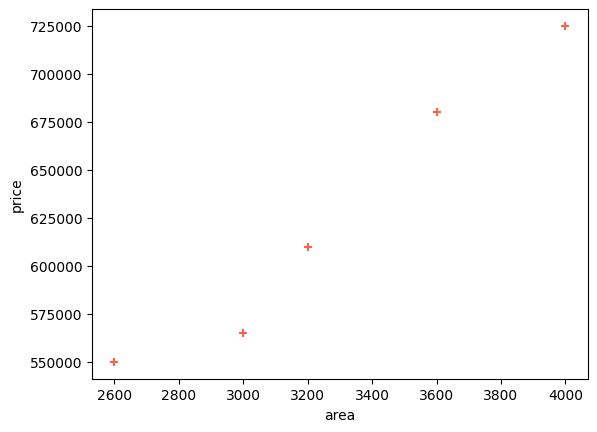

In [4]:
plt.xlabel('area')
plt.ylabel('price')
plt.scatter(df.area,df.price,color='tomato',marker='+')
plt.show()

In [5]:
X = df[['area']]
X

,area
0,2600
1,3000
2,3200
3,3600
4,4000


In [6]:
y = df[['price']]
y

,price
0,550000
1,565000
2,610000
3,680000
4,725000


In [7]:
# Create linear regression object
reg = linear_model.LinearRegression()
reg.fit(X,y) #training the model

LinearRegression()

### *Now since our model is trained we can ask our questions to predict the price:*

***1) Predict price of a home with area = 3300 sqr ft***

In [8]:
reg.predict([[3300]])

array([[628715.75342466]])

- Lets verify with our concept to check if it is correct/not:

In [9]:
reg.coef_

array([[135.78767123]])

In [10]:
reg.intercept_

array([180616.43835616])

Now, we know y = m*area + intercept\
**Y = m * X + b (m is coefficient and b is intercept)**

In [11]:
3300*135.78767123+180616.43835616

628715.75341516

***2) Predict price of a home with  area = 5000 sqr ft***

In [12]:
reg.predict([[5000]])

array([[859554.79452055]])

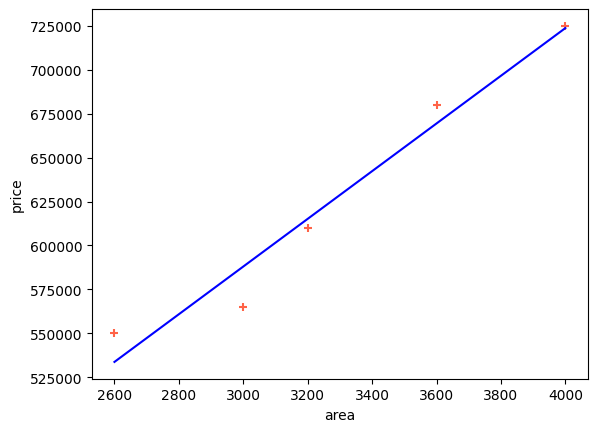

In [13]:
plt.xlabel('area')
plt.ylabel('price')
plt.scatter(df.area,df.price,color='tomato',marker='+')
plt.plot(df.area,reg.predict(df[['area']]),color="blue")
plt.show()

### <font style="color:salmon;">***We can also check the score of our model like this:***</font>

In [14]:
reg.score(X,y)*100 # multiplying with 100 with get the actual percentage

95.84301138199486

### <font style="color:green;">***Saving the prediction into an csv file after testing it:***</font>

In [15]:
area_df = pd.read_csv("areas.csv")
area_df.head(3)

,area
0,1000
1,1500
2,2300


In [16]:
predictions = reg.predict(area_df)
predictions

array([[ 316404.10958904],
       [ 384297.94520548],
       [ 492928.08219178],
       [ 661304.79452055],
       [ 740061.64383562],
       [ 799808.21917808],
       [ 926090.75342466],
       [ 650441.78082192],
       [ 825607.87671233],
       [ 492928.08219178],
       [1402705.47945205],
       [1348390.4109589 ],
       [1144708.90410959]])

In [17]:
area_df['predicted prices']=predictions
area_df

,area,predicted prices
0,1000,3.164041e+05
1,1500,3.842979e+05
2,2300,4.929281e+05
3,3540,6.613048e+05
4,4120,7.400616e+05
5,4560,7.998082e+05
6,5490,9.260908e+05
7,3460,6.504418e+05
8,4750,8.256079e+05
9,2300,4.929281e+05


In [18]:
area_df.to_csv("predicted_prices_by_model.csv",index=False)